In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [ ]:

df = pd.read_excel('datacenter_outliers_CAPPED.xlsx')


print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nFirst few rows:")
print(df.head())

Dataset loaded!
Shape: (20000, 23)
Columns: 23
Rows: 20000

Missing values: 18800

First few rows:
  CPU state  Ambient T (ÂºC)  Oil flow (l/min)  FAN (% max )   T air in  \
0      Idle        31.184652          3.453896     43.418909  31.060505   
1      High        30.555197          5.629523     78.449678  30.520545   
2       Off        27.017107          0.602723     25.266293  28.541348   
3      Idle        28.848405          3.596242     52.358562  27.085365   
4  Moderate        33.030421          3.976994     45.753771  33.668374   

    Tair out   T oil in  T oil out     Tcpu 1     Tcpu 2  ...  Average T  \
0  33.644669  42.542376  47.061275  53.608069  53.767733  ...  44.801826   
1  43.769525  50.707682  57.355750  82.339849  78.286410  ...  54.031716   
2  30.525848  32.754515  31.831677  32.461309  31.686017  ...  32.268729   
3  33.699585  39.485993  42.217545  54.266064  56.328063  ...  40.851769   
4  37.326649  49.773882  52.389629  65.950436  64.720685  ...  51.0817

In [ ]:
# Check what columns you have
print("All columns:")
print(df.columns.tolist())

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Basic statistics
print(f"\nBasic statistics:")
print(df.describe())

All columns:
['CPU state', 'Ambient T (ÂºC)', 'Oil flow (l/min)', 'FAN (% max )', 'T air in', 'Tair out', 'T oil in', 'T oil out', 'Tcpu 1', 'Tcpu 2', 'Density (Kg/l)', 'g/s', 'delta T', 'Average T', 'Cp oil (J/gr K)', 'Power (W)', 'HX effic', 'Pump consumption (W)', 'Fan consumption W', 'Edge consumption (W)', 'MAX dT liquid-air (inlet)', 'anomaly', 'anomaly_type']

Data types:
CPU state                     object
Ambient T (ÂºC)              float64
Oil flow (l/min)             float64
FAN (% max )                 float64
T air in                     float64
Tair out                     float64
T oil in                     float64
T oil out                    float64
Tcpu 1                       float64
Tcpu 2                       float64
Density (Kg/l)               float64
g/s                          float64
delta T                      float64
Average T                    float64
Cp oil (J/gr K)              float64
Power (W)                    float64
HX effic                  

In [ ]:
# Get correlations with target (Tcpu 1)
target = 'Tcpu 1'
numeric_cols = df.select_dtypes(include=[np.number]).columns

correlations = df[numeric_cols].corrwith(df[target]).sort_values(ascending=False)

print("Correlations with Tcpu 1 (target):")
print("="*50)
for feature, corr in correlations.items():
    print(f"{feature:30s}: {corr:7.4f}")

Correlations with Tcpu 1 (target):
Tcpu 1                        :  1.0000
Tcpu 2                        :  0.9904
T oil out                     :  0.9558
Average T                     :  0.9492
MAX dT liquid-air (inlet)     :  0.9267
g/s                           :  0.9234
T oil in                      :  0.9170
Cp oil (J/gr K)               :  0.9170
FAN (% max )                  :  0.9160
Pump consumption (W)          :  0.9141
Oil flow (l/min)              :  0.8996
Fan consumption W             :  0.8768
Power (W)                     :  0.8587
Tair out                      :  0.8361
delta T                       :  0.8269
T air in                      :  0.1373
Ambient T (ÂºC)               :  0.1216
anomaly                       :  0.0602
Edge consumption (W)          :  0.0081
HX effic                      : -0.3619
Density (Kg/l)                : -0.9170


In [ ]:
print("Features to DROP:")
print("="*60)

# These are REDUNDANT - drop them
features_to_drop = [
    'Tcpu 2',                    # r=0.9904 - Perfect correlation (redundant!)
    'Density (Kg/l)',            # Derived from temperature
    'Cp oil (J/gr K)',           # Derived from temperature
    'g/s',                       # Calculated as: Oil flow × Density
    'HX effic',                  # Independent from temperature (r ≈ -0.36)
    'Edge consumption (W)',      # Constant 50W baseline
    'anomaly_type',              # Not needed for prediction
    'CPU state',                 # Not needed for prediction
    'T air in',                  # Very weak signal (r=0.137)
    'Ambient T (ÂºC)',           # Bad encoding (r=0.121)
]

for f in features_to_drop:
    print(f"  - {f}")

# Drop them
df_model = df.drop(features_to_drop, axis=1, inplace=False)

print(f"\n✅ After dropping: {df_model.shape}")
print(f"\nRemaining columns:")
print(df_model.columns.tolist())

# Prepare X (features) and y (target)
target = 'Tcpu 1'
X = df_model.drop([target, 'anomaly'], axis=1)
y = df_model[target]

print(f"\n✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

print(f"\nYour FEATURES ({X.shape[1]} total):")
print("="*60)
for i, col in enumerate(X.columns, 1):
    corr = df[col].corr(df[target])
    print(f"  {i:2d}. {col:35s} (r={corr:7.4f})")

Features to DROP:
  - Tcpu 2
  - Density (Kg/l)
  - Cp oil (J/gr K)
  - g/s
  - HX effic
  - Edge consumption (W)
  - anomaly_type
  - CPU state
  - T air in
  - Ambient T (ÂºC)

✅ After dropping: (20000, 13)

Remaining columns:
['Oil flow (l/min)', 'FAN (% max )', 'Tair out', 'T oil in', 'T oil out', 'Tcpu 1', 'delta T', 'Average T', 'Power (W)', 'Pump consumption (W)', 'Fan consumption W', 'MAX dT liquid-air (inlet)', 'anomaly']

✅ X shape: (20000, 11)
✅ y shape: (20000,)

Your FEATURES (11 total):
   1. Oil flow (l/min)                    (r= 0.8996)
   2. FAN (% max )                        (r= 0.9160)
   3. Tair out                            (r= 0.8361)
   4. T oil in                            (r= 0.9170)
   5. T oil out                           (r= 0.9558)
   6. delta T                             (r= 0.8269)
   7. Average T                           (r= 0.9492)
   8. Power (W)                           (r= 0.8587)
   9. Pump consumption (W)                (r= 0.9141)
  10. Fa

In [ ]:
df.drop("anomaly", axis=1, inplace=True)

In [ ]:
X['Oil_x_FAN'] = X['Oil flow (l/min)'] * X['FAN (% max )']
X['Power_x_Oil'] = X['Power (W)'] * X['Oil flow (l/min)']
X['T_Out_x_Power'] = X['T oil out'] * X['Power (W)']
X['Fan_per_Power'] = X['FAN (% max )'] / (X['Power (W)'] + 1)
X['Pump_Power_Ratio'] = X['Pump consumption (W)'] / (X['Power (W)'] + 1)
X['T_Out_minus_In'] = X['T oil out'] - X['T oil in']
X['Power_minus_Pump'] = X['Power (W)'] - X['Pump consumption (W)']
X['Power_Squared'] = X['Power (W)'] ** 2
X['Log_Power'] = np.log1p(X['Power (W)'])

In [ ]:
# CRITICAL: Verify you have these features
must_have = ['T oil out', 'Average T', 'FAN (% max )', 'Power (W)', 'Oil flow (l/min)']

print("Checking critical features:")
print("="*60)
for feature in must_have:
    if feature in X.columns:
        print(f"✅ {feature}")
    else:
        print(f"❌ MISSING: {feature}")

# Check for bad features
print(f"\nChecking for bad features:")
if 'Tcpu 2' in X.columns:
    print(f"❌ TCPU 2 FOUND (should be dropped!)")
else:
    print(f"✅ Tcpu 2 is not in features (good!)")

print(f"\nFinal feature count: {X.shape[1]} (should be around 11-12)")

Checking critical features:
✅ T oil out
✅ Average T
✅ FAN (% max )
✅ Power (W)
✅ Oil flow (l/min)

Checking for bad features:
✅ Tcpu 2 is not in features (good!)

Final feature count: 20 (should be around 11-12)


In [ ]:
# Split data: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train-Test Split:")
print("="*60)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")
print(f"Total:            {len(X_train) + len(X_test):,}")
print(f"Train-Test ratio: {len(X_train)/(len(X_train)+len(X_test)):.1%}")

# Verify target distribution
print(f"\nTarget (Tcpu 1) distribution:")
print(f"  Train - Mean: {y_train.mean():.2f}°C, Std: {y_train.std():.2f}°C")
print(f"  Test  - Mean: {y_test.mean():.2f}°C, Std: {y_test.std():.2f}°C")

Train-Test Split:
Training samples: 14,000
Testing samples:  6,000
Total:            20,000
Train-Test ratio: 70.0%

Target (Tcpu 1) distribution:
  Train - Mean: 60.25°C, Std: 14.88°C
  Test  - Mean: 60.27°C, Std: 14.69°C


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# CRITICAL: Fit on training data ONLY
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Don't fit again!

# Convert back to DataFrame (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verify scaling
print("Feature Scaling Verification:")
print("="*60)
print(f"Training set:")
print(f"  Mean: {X_train_scaled.mean().mean():.6f} (should be ~0)")
print(f"  Std:  {X_train_scaled.std().mean():.6f} (should be ~1)")

print(f"\nTest set:")
print(f"  Mean: {X_test_scaled.mean().mean():.6f}")
print(f"  Std:  {X_test_scaled.std().mean():.6f}")

print(f"\n✅ Scaling complete!")

Feature Scaling Verification:
Training set:
  Mean: 0.000000 (should be ~0)
  Std:  1.000036 (should be ~1)

Test set:
  Mean: 0.003375
  Std:  0.993280

✅ Scaling complete!


In [ ]:
# Train Linear Regression
print("Training Linear Regression...")
print("="*60)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr = lr_model.predict(X_test_scaled)

# Evaluate
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))
r2_train_lr = r2_score(y_train, y_pred_train_lr)
r2_test_lr = r2_score(y_test, y_pred_test_lr)
mae_test_lr = mean_absolute_error(y_test, y_pred_test_lr)

print(f"\nLinear Regression Results:")
print(f"  Train R²: {r2_train_lr:.4f}")
print(f"  Test R²:  {r2_test_lr:.4f}")
print(f"  Test RMSE: {rmse_test_lr:.3f}°C")
print(f"  Test MAE:  {mae_test_lr:.3f}°C")

# Check for overfitting
overfit = r2_train_lr - r2_test_lr
if overfit < 0.02:
    print(f"  ✅ Good generalization (diff = {overfit:.4f})")
else:
    print(f"  ⚠️  Possible overfitting (diff = {overfit:.4f})")

Training Linear Regression...

Linear Regression Results:
  Train R²: 0.9497
  Test R²:  0.9482
  Test RMSE: 3.342°C
  Test MAE:  2.601°C
  ✅ Good generalization (diff = 0.0015)


In [ ]:
# Train Random Forest
print("Training Random Forest...")
print("="*60)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_test_rf = rf_model.predict(X_test_scaled)

# Evaluate
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)

print(f"\nRandom Forest Results:")
print(f"  Train R²: {r2_train_rf:.4f}")
print(f"  Test R²:  {r2_test_rf:.4f}")
print(f"  Test RMSE: {rmse_test_rf:.3f}°C")
print(f"  Test MAE:  {mae_test_rf:.3f}°C")

overfit = r2_train_rf - r2_test_rf
if overfit < 0.05:
    print(f"  ✅ Good generalization (diff = {overfit:.4f})")
else:
    print(f"  ⚠️  Possible overfitting (diff = {overfit:.4f})")

Training Random Forest...

Random Forest Results:
  Train R²: 0.9825
  Test R²:  0.9511
  Test RMSE: 3.249°C
  Test MAE:  2.561°C
  ✅ Good generalization (diff = 0.0314)


In [ ]:
# Train XGBoost
print("Training XGBoost...")
print("="*60)

xgb_model = xgb.XGBRegressor(
    n_estimators=400,           # Number of trees
    max_depth=4,                # Tree depth
    learning_rate=0.05,          # Learning rate
    subsample=0.8,              # Sample 80% of data per tree
    colsample_bytree=0.8,       # Sample 80% of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1,                  # Use all CPUs
    verbose=0                   # No output during training
)

xgb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train_xgb = xgb_model.predict(X_train_scaled)
y_pred_test_xgb = xgb_model.predict(X_test_scaled)

# Evaluate
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)

print(f"\nXGBoost Results:")
print(f"  Train R²: {r2_train_xgb:.4f}")
print(f"  Test R²:  {r2_test_xgb:.4f}")
print(f"  Test RMSE: {rmse_test_xgb:.3f}°C")
print(f"  Test MAE:  {mae_test_xgb:.3f}°C")

overfit = r2_train_xgb - r2_test_xgb
if overfit < 0.02:
    print(f"  ✅ Good generalization (diff = {overfit:.4f})")
else:
    print(f"  ⚠️  Possible overfitting (diff = {overfit:.4f})")

Training XGBoost...

XGBoost Results:
  Train R²: 0.9631
  Test R²:  0.9521
  Test RMSE: 3.216°C
  Test MAE:  2.533°C
  ✅ Good generalization (diff = 0.0110)



MODEL COMPARISON
            Model  Train R²  Test R²  Test RMSE  Test MAE
Linear Regression  0.949725 0.948225   3.342221  2.601394
    Random Forest  0.982486 0.951058   3.249491  2.561403
          XGBoost  0.963050 0.952065   3.215886  2.532632

🏆 BEST MODEL: XGBoost


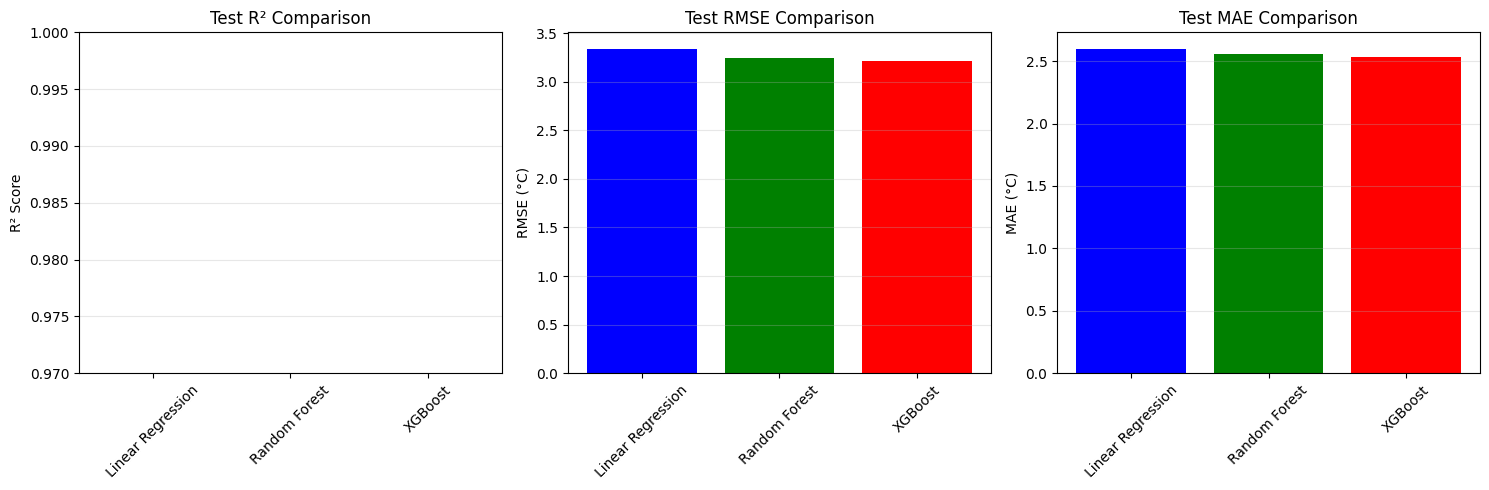

✓ Saved: model_comparison.png


In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train R²': [r2_train_lr, r2_train_rf, r2_train_xgb],
    'Test R²': [r2_test_lr, r2_test_rf, r2_test_xgb],
    'Test RMSE': [rmse_test_lr, rmse_test_rf, rmse_test_xgb],
    'Test MAE': [mae_test_lr, mae_test_rf, mae_test_xgb],
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Find best model
best_model_idx = comparison_df['Test R²'].idxmax()
best_model = comparison_df.iloc[best_model_idx]['Model']
print(f"\n🏆 BEST MODEL: {best_model}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² comparison
axes[0].bar(comparison_df['Model'], comparison_df['Test R²'], color=['blue', 'green', 'red'])
axes[0].set_ylabel('R² Score')
axes[0].set_ylim([0.97, 1.0])
axes[0].set_title('Test R² Comparison')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE comparison
axes[1].bar(comparison_df['Model'], comparison_df['Test RMSE'], color=['blue', 'green', 'red'])
axes[1].set_ylabel('RMSE (°C)')
axes[1].set_title('Test RMSE Comparison')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[2].bar(comparison_df['Model'], comparison_df['Test MAE'], color=['blue', 'green', 'red'])
axes[2].set_ylabel('MAE (°C)')
axes[2].set_title('Test MAE Comparison')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: model_comparison.png")


Creating SHAP explainer... (30 seconds)
✅ SHAP values ready!

DETAILED PREDICTION EXPLANATIONS

SAMPLE #0

📌 SUMMARY:
   Baseline (average):    60.25°C
   Predicted:             34.92°C
   Actual:                32.46°C
   Error:                 -2.46°C

📊 HOW FEATURES CHANGE THE PREDICTION:
Feature                                  Value        SHAP       Effect         
-----------------------------------------------------------------------------
START (BASELINE)                         -            -          60.25°C
-----------------------------------------------------------------------------
T oil out                                     -1.874   -14.261 ↓ DOWN -14.261°C
Average T                                     -1.694    -2.563 ↓ DOWN -2.563°C
FAN (% max )                                  -1.131    -2.539 ↓ DOWN -2.539°C
Pump consumption (W)                          -1.434    -2.284 ↓ DOWN -2.284°C
Oil_x_FAN                                     -1.221    -1.941 ↓ DOWN -1.941°C


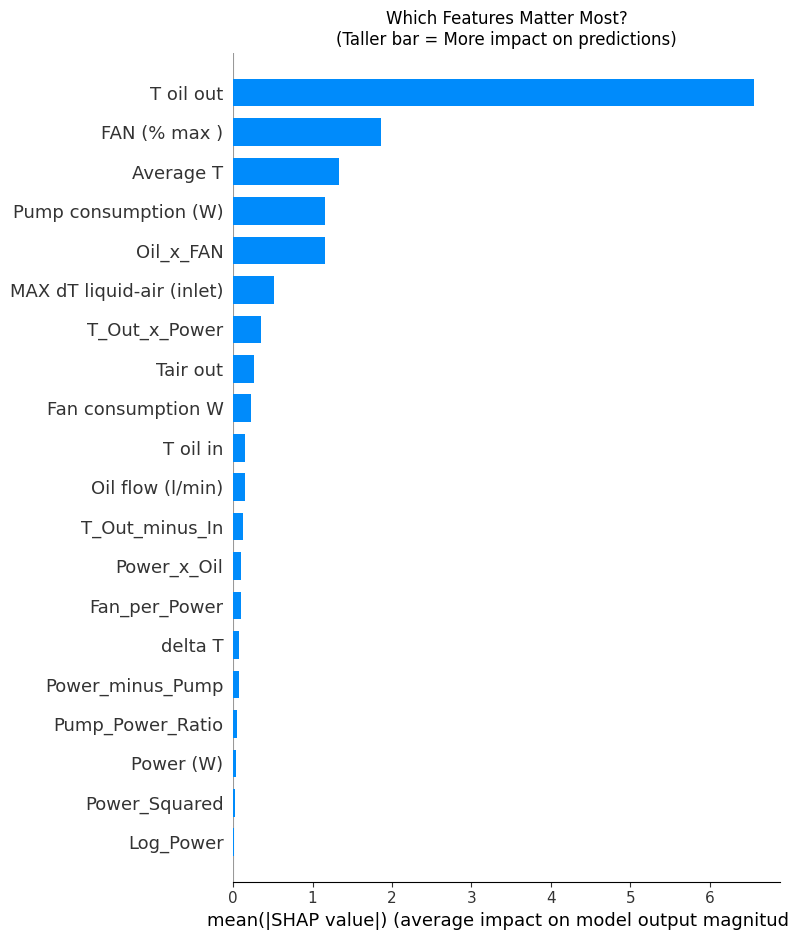

[2/4] Detailed beeswarm plot...


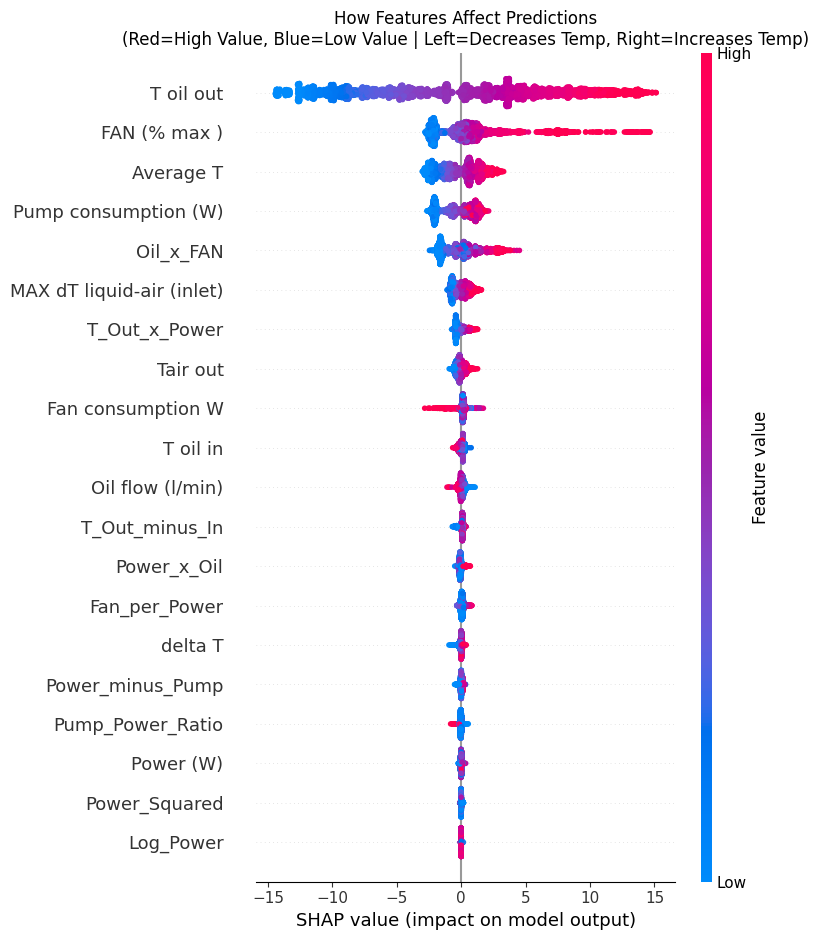

[3/4] Force plot (waterfall view)...


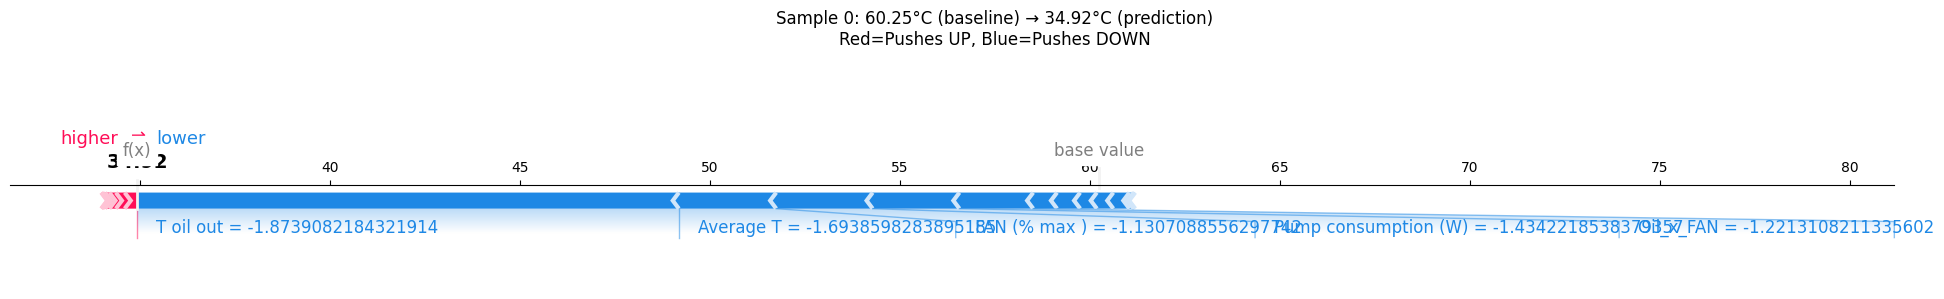

[4/4] Waterfall plot (most detailed)...


TypeError: waterfall() got an unexpected keyword argument 'ax'

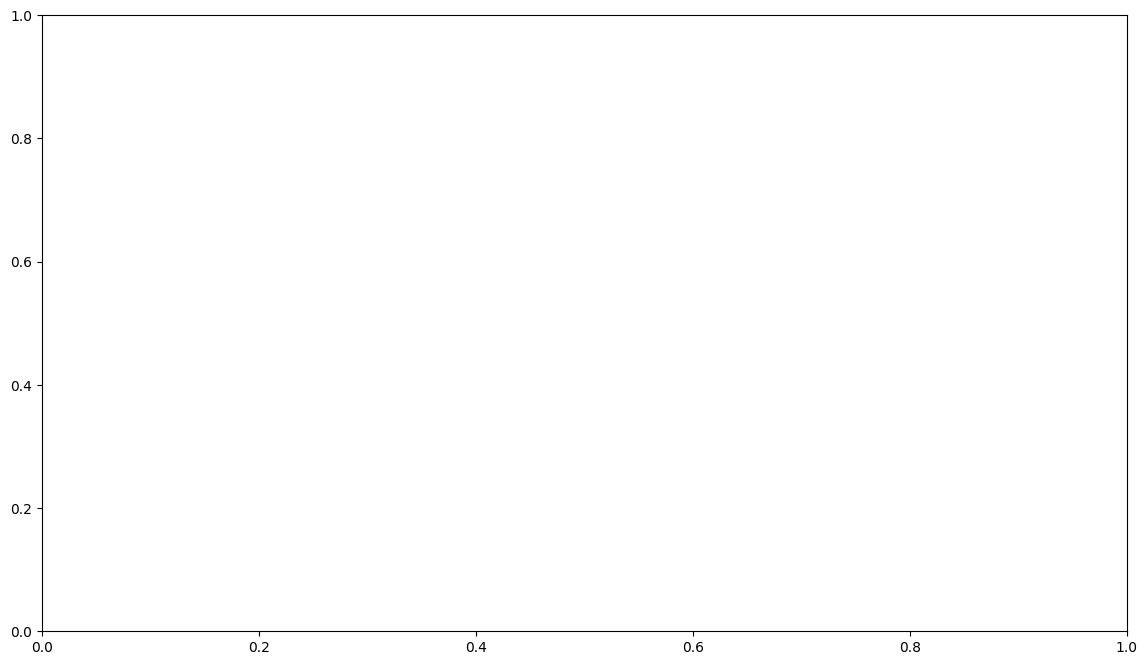

In [ ]:
import shap # Import shap library
import matplotlib.pyplot as plt # Ensure plt is imported for force_plot and waterfall_plot

print("\nCreating SHAP explainer... (30 seconds)")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
print("✅ SHAP values ready!")

# 6. DETAILED EXPLANATION FOR 3 SAMPLES
print("\n" + "="*80)
print("DETAILED PREDICTION EXPLANATIONS")
print("="*80)

# Using y_pred_test_xgb as it's the output of the best model (XGBoost)
y_pred = y_pred_test_xgb

for sample_idx in [0, 100, 500]:
    baseline = explainer.expected_value
    actual = y_test.iloc[sample_idx]
    predicted = y_pred[sample_idx]
    sample_shap = shap_values[sample_idx]
    sample_features = X_test_scaled.iloc[sample_idx]

    print(f"\n{'='*80}")
    print(f"SAMPLE #{sample_idx}")
    print(f"{'='*80}")

    print(f"\n📌 SUMMARY:")
    print(f"   Baseline (average):    {baseline:.2f}°C")
    print(f"   Predicted:             {predicted:.2f}°C")
    print(f"   Actual:                {actual:.2f}°C")
    print(f"   Error:                 {actual-predicted:+.2f}°C")

    print(f"\n📊 HOW FEATURES CHANGE THE PREDICTION:")
    print(f"{'Feature':<40} {'Value':<12} {'SHAP':<10} {'Effect':<15}")
    print(f"{'-'*77}")
    print(f"{'START (BASELINE)':<40} {'-':<12} {'-':<10} {baseline:.2f}°C")
    print(f"{'-'*77}")

    # Create contribution dataframe
    contributions = pd.DataFrame({
        'Feature': X.columns,
        'Value': sample_features.values,
        'SHAP': sample_shap
    }).sort_values('SHAP', ascending=False, key=abs)

    cumulative = baseline
    for _, row in contributions.head(12).iterrows():
        cumulative += row['SHAP']
        direction = "↑ UP" if row['SHAP'] > 0 else "↓ DOWN"
        print(f"{row['Feature']:<40} {row['Value']:>11.3f} {row['SHAP']:>9.3f} {direction:>6} {row['SHAP']:+.3f}°C")

    print(f"{'-'*77}")
    print(f"{'FINAL PREDICTION':<40} {'-':<12} {'-':<10} {predicted:.2f}°C")
    print(f"\n✅ Verification: {baseline:.2f} + (feature contributions) = {predicted:.2f}°C")

# 7. GENERATE VISUALIZATIONS
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Bar plot
print("\n[1/4] Importance bar chart...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title("Which Features Matter Most?\n(Taller bar = More impact on predictions)")
plt.tight_layout()
plt.savefig('shap_01_importance.png', dpi=300)
plt.show()
plt.close() # Explicitly close the figure

# Beeswarm
print("[2/4] Detailed beeswarm plot...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("How Features Affect Predictions\n(Red=High Value, Blue=Low Value | Left=Decreases Temp, Right=Increases Temp)")
plt.tight_layout()
plt.savefig('shap_02_beeswarm.png', dpi=300)
plt.show()
plt.close() # Explicitly close the figure

# Force plot
print("[3/4] Force plot (waterfall view)...")
sample_idx = 0
# shap.force_plot returns a matplotlib Figure object when matplotlib=True
fig_force = shap.force_plot(explainer.expected_value, shap_values[sample_idx],
                X_test_scaled.iloc[sample_idx], feature_names=X.columns,
                matplotlib=True, show=False)

# Add suptitle to the figure returned by force_plot
fig_force.suptitle(f"Sample {sample_idx}: {explainer.expected_value:.2f}°C (baseline) → {y_pred[sample_idx]:.2f}°C (prediction)\nRed=Pushes UP, Blue=Pushes DOWN")
fig_force.tight_layout() # Apply tight_layout to the specific figure
fig_force.savefig('shap_03_force.png', dpi=300, bbox_inches='tight') # Save the specific figure
plt.show(fig_force) # Display the specific figure
plt.close(fig_force) # Close the specific figure to free memory

# Waterfall (most detailed!)
print("[4/4] Waterfall plot (most detailed)...")
fig_waterfall, ax_waterfall = plt.subplots(figsize=(14, 8)) # Create a new figure and axes
shap.waterfall_plot(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled.iloc[sample_idx],
    feature_names=X.columns
), show=False, ax=ax_waterfall) # Pass the ax to waterfall_plot
ax_waterfall.set_title(f"Complete Breakdown: {explainer.expected_value:.2f}°C (start) + features = {y_pred[sample_idx]:.2f}°C (end)")
fig_waterfall.tight_layout()
fig_waterfall.savefig('shap_04_waterfall.png', dpi=300, bbox_inches='tight')
plt.show(fig_waterfall)
plt.close(fig_waterfall)

# 8. FEATURE IMPORTANCE TABLE
print("\n" + "="*80)
print("FEATURE IMPORTANCE RANKING (Average Impact)")
print("="*80)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Avg_Impact': mean_abs_shap
}).sort_values('Avg_Impact', ascending=False)

print(f"\n{'Feature':<40} {'Average Impact':<15} {'Interpretation':<20}")
print(f"{'-'*75}")
for _, row in importance.head(15).iterrows():
    if row['Avg_Impact'] > 0.05:
        importance_level = "CRITICAL"
    elif row['Avg_Impact'] > 0.02:
        importance_level = "VERY IMPORTANT"
    elif row['Avg_Impact'] > 0.01:
        importance_level = "IMPORTANT"
    else:
        importance_level = "MINOR"

    print(f"{row['Feature']:<40} ±{row['Avg_Impact']:>8.4f}°C    {importance_level:<20}")

print("\n✅ COMPLETE!")

In [ ]:
print("\n" + "="*80)
print("STEP 1: SAVING YOUR MODEL FOR PRODUCTION")
print("="*80)

import joblib
import json
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# PART 1.1: Save Model
# ─────────────────────────────────────────────────────────────────────────────

try:
    joblib.dump(xgb_model, 'xgboost_tcpu_model.pkl')
    print("✅ Model saved: xgboost_tcpu_model.pkl")
except Exception as e:
    print(f"❌ Error saving model: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# PART 1.2: Save Scaler
# ─────────────────────────────────────────────────────────────────────────────

try:
    joblib.dump(scaler, 'scaler.pkl')
    print("✅ Scaler saved: scaler.pkl")
except Exception as e:
    print(f"❌ Error saving scaler: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# PART 1.3: Save Feature Names
# ─────────────────────────────────────────────────────────────────────────────

try:
    feature_names = X.columns.tolist()
    with open('feature_names.txt', 'w') as f:
        f.write('\n'.join(feature_names))
    print("✅ Feature names saved: feature_names.txt")
    print(f"   Total features: {len(feature_names)}")
    print("   Features:")
    for i, fname in enumerate(feature_names, 1):
        print(f"     {i}. {fname}")
except Exception as e:
    print(f"❌ Error saving features: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# PART 1.4: Save Model Metadata
# ─────────────────────────────────────────────────────────────────────────────

try:
    # Get performance metrics (you already have these from training)
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

    # Calculate if not already done
    y_pred_test = xgb_model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)

    model_metadata = {
        'model_name': 'CPU Temperature Prediction',
        'model_type': 'XGBoost',
        'version': '1.0.0',
        'target_variable': 'Tcpu 1',
        'target_unit': '°C',
        'total_features': len(feature_names),
        'feature_names': feature_names,
        'model_performance': {
            'r2_score': float(r2),
            'rmse': float(rmse),
            'mae': float(mae),
            'accuracy_percentage': float(r2 * 100)
        },
        'training_info': {
            'total_samples': len(X),
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'train_test_split': '70-30'
        },
        'hyperparameters': {
            'n_estimators': 200,
            'max_depth': 7,
            'learning_rate': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8
        }
    }

    with open('model_metadata.json', 'w') as f:
        json.dump(model_metadata, f, indent=2)

    print("✅ Metadata saved: model_metadata.json")
    print(f"\n   Model Performance:")
    print(f"   - R² Score: {r2:.4f}")
    print(f"   - RMSE: {rmse:.3f}°C")
    print(f"   - MAE: {mae:.3f}°C")

except Exception as e:
    print(f"❌ Error saving metadata: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# PART 1.5: Download Instructions
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("IMPORTANT: DOWNLOAD THESE 4 FILES FROM COLAB")
print("="*80)
print("""
STEPS:
  1. Click "Files" icon on left sidebar
  2. Look for these 4 files:
     - xgboost_tcpu_model.pkl      (Model file)
     - scaler.pkl                   (Scaling file)
     - feature_names.txt            (Feature list)
     - model_metadata.json          (Model info)

  3. Right-click each file → Download

  4. Save all 4 files in a folder on your computer:
     C:\\Users\\YourName\\ml_backend_files\\
     OR
     /Users/YourName/ml_backend_files/

THESE 4 FILES ARE YOUR ENTIRE MODEL - KEEP THEM SAFE!
""")

print("✅ STEP 1 COMPLETE - Your model is ready for production!")


STEP 1: SAVING YOUR MODEL FOR PRODUCTION
✅ Model saved: xgboost_tcpu_model.pkl
✅ Scaler saved: scaler.pkl
✅ Feature names saved: feature_names.txt
   Total features: 20
   Features:
     1. Oil flow (l/min)
     2. FAN (% max )
     3. Tair out
     4. T oil in
     5. T oil out
     6. delta T
     7. Average T
     8. Power (W)
     9. Pump consumption (W)
     10. Fan consumption W
     11. MAX dT liquid-air (inlet)
     12. Oil_x_FAN
     13. Power_x_Oil
     14. T_Out_x_Power
     15. Fan_per_Power
     16. Pump_Power_Ratio
     17. T_Out_minus_In
     18. Power_minus_Pump
     19. Power_Squared
     20. Log_Power
✅ Metadata saved: model_metadata.json

   Model Performance:
   - R² Score: 0.9521
   - RMSE: 3.216°C
   - MAE: 2.533°C

IMPORTANT: DOWNLOAD THESE 4 FILES FROM COLAB

STEPS:
  1. Click "Files" icon on left sidebar
  2. Look for these 4 files:
     - xgboost_tcpu_model.pkl      (Model file)
     - scaler.pkl                   (Scaling file)
     - feature_names.txt      